# HistGradientBoosting

## Qué cambia respecto al notebook original
- se corrige el bloque de **interacciones**, que estaba mezclando `df_train` y `df_test` en el mismo diccionario;
- se sacan del modelo base las columnas de **alta cardinalidad / texto libre** (`PetID`, `Name`, `Description`, `RescuerID`);
- se deja una preparación compatible con **categóricas nativas** de HistGradientBoosting;
- se agregan:
  - baseline simple
  - validación cruzada 5-fold
  - curva de desempeño por iteración
  - permutation importance
  - Optuna opcional


In [25]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

SEED = 42
TEST_SIZE = 0.20
N_SPLITS = 5
TARGET_COL = "AdoptionSpeed"


## 1. Carga de archivos

Dejo la misma lógica de rutas de tu notebook original. Si tu carpeta cambió, ajustá `BASE_DIR`.


In [26]:
BASE_DIR = r"C:\Users\Kevin\Downloads\petfinder-adoption-prediction\train"

breed_df = pd.read_csv(os.path.join(BASE_DIR, "breed_labels.csv"))
color_df = pd.read_csv(os.path.join(BASE_DIR, "color_labels.csv"))
state_df = pd.read_csv(os.path.join(BASE_DIR, "state_labels.csv"))
train_df = pd.read_csv(os.path.join(BASE_DIR, "train.csv"), sep=";", encoding="latin-1")

print("train_df:", train_df.shape)
print("breed_df:", breed_df.shape)
display(train_df.head(3))


train_df: (14993, 24)
breed_df: (307, 3)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,10,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,20,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,70,3


## 2. Split train / test estratificado


In [27]:
df_train, df_test = train_test_split(
    train_df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=train_df[TARGET_COL]
)

print("df_train:", df_train.shape)
print("df_test :", df_test.shape)
print("\nDistribución del target en train:")
print(df_train[TARGET_COL].value_counts(normalize=True).sort_index().round(4))
print("\nDistribución del target en test:")
print(df_test[TARGET_COL].value_counts(normalize=True).sort_index().round(4))
 

df_train: (11994, 24)
df_test : (2999, 24)

Distribución del target en train:
AdoptionSpeed
0    0.0273
1    0.2061
2    0.2693
3    0.2174
4    0.2799
Name: proportion, dtype: float64

Distribución del target en test:
AdoptionSpeed
0    0.0273
1    0.2061
2    0.2691
3    0.2174
4    0.2801
Name: proportion, dtype: float64


## 3. Crear `SizeCategory` a partir de `breed_labels`

Mantengo tu idea de categorizar el tamaño aproximado de la raza base.


In [28]:
def categorizar_tamano(row):
    breed = str(row["BreedName"]).lower()
    pet_type = row["Type"]

    if pet_type == 2:
        return "Pequeño"

    if "mixed breed" in breed:
        return "Mediano"

    excepciones_grandes = [
        "black russian terrier", "airedale terrier", "afghan hound",
        "bloodhound", "greyhound", "irish wolfhound"
    ]
    excepciones_medianos = [
        "american staffordshire terrier", "pit bull terrier", "bull terrier",
        "beagle", "basset hound", "whippet", "standard schnauzer", "cocker spaniel"
    ]
    excepciones_pequenos = ["dachshund", "miniature schnauzer", "toy", "miniature"]

    if any(exc in breed for exc in excepciones_grandes):
        return "Grande"
    if any(exc in breed for exc in excepciones_medianos):
        return "Mediano"
    if any(exc in breed for exc in excepciones_pequenos):
        return "Pequeño"

    keywords_pequenos = [
        "terrier", "chihuahua", "pomeranian", "pug", "shih tzu", "maltese",
        "pekingese", "corgi", "bichon", "french bulldog", "papillon",
        "havanese", "pinscher"
    ]
    keywords_grandes = [
        "retriever", "shepherd", "mastiff", "great", "husky", "malamute",
        "akita", "hound", "pointer", "setter", "collie", "rottweiler",
        "doberman", "boxer", "american bulldog", "sheepdog", "dane",
        "bernard", "pyrenees", "newfoundland", "weimaraner", "ridgeback",
        "corso", "komondor", "kuvasz", "borzoi", "dalmatian"
    ]

    if any(kw in breed for kw in keywords_pequenos):
        return "Pequeño"
    if any(kw in breed for kw in keywords_grandes):
        return "Grande"

    return "Mediano"

breed_df = breed_df.copy()
breed_df["SizeCategory"] = breed_df.apply(categorizar_tamano, axis=1)

def merge_size_category(df):
    df = df.merge(
        breed_df[["BreedID", "SizeCategory"]],
        left_on="Breed1",
        right_on="BreedID",
        how="left"
    )
    return df.drop(columns=["BreedID"])

df_train = merge_size_category(df_train)
df_test = merge_size_category(df_test)

print(df_train[["Breed1", "SizeCategory"]].head())


   Breed1 SizeCategory
0     307      Mediano
1     307      Mediano
2     307      Mediano
3     307      Mediano
4     265      Pequeño


## 4. Interacciones corregidas

Acá está la corrección importante: cada dataset genera sus propias features.  
En tu notebook original, el diccionario `nuevas_features` pisaba columnas de train con columnas de test.


In [29]:
def agregar_interacciones(df):
    df = df.copy()

    df["Age_x_MaturitySize"] = df["Age"] * df["MaturitySize"]
    df["Fee_x_Breed1"] = df["Fee"] * df["Breed1"]
    df["Age_x_PhotoAmt"] = df["Age"] * df["PhotoAmt"]
    df["Salud_Completa"] = df["Vaccinated"] * df["Dewormed"] * df["Sterilized"]
    df["Photos_per_Pet"] = df["PhotoAmt"] / (df["Quantity"] + 1)
    df["Breed_x_Color1"] = df["Breed1"] * df["Color1"]

    return df

df_train = agregar_interacciones(df_train)
df_test = agregar_interacciones(df_test)

print("df_train con interacciones:", df_train.shape)
print("df_test con interacciones :", df_test.shape)


df_train con interacciones: (11994, 31)
df_test con interacciones : (2999, 31)


## 5. Preparación para HistGradientBoosting

### Decisiones de modelado
Para la versión base voy a **excluir**:
- `PetID`
- `Name`
- `Description`
- `RescuerID`

Motivo:
- son columnas de ID o texto libre;
- HistGradientBoosting soporta categóricas nativas, pero cada feature categórica debe tener **como máximo `max_bins` categorías**;
- además, `PetID` y `Description` no son buenas categóricas “nativas” para este modelo.

También voy a colapsar categorías raras en `Breed1` y `Breed2` para no chocar con el límite de cardinalidad.


In [30]:
DROP_COLS = [TARGET_COL, "PetID", "Name", "Description", "RescuerID"]

X_train = df_train.drop(columns=[c for c in DROP_COLS if c in df_train.columns]).copy()
y_train = df_train[TARGET_COL].copy()

X_test = df_test.drop(columns=[c for c in DROP_COLS if c in df_test.columns]).copy()
y_test = df_test[TARGET_COL].copy()

cat_cols = [
    "Type", "Breed1", "Breed2", "Gender", "Color1", "Color2", "Color3",
    "Vaccinated", "Dewormed", "Sterilized", "Health", "State", "SizeCategory"
]
cat_cols = [c for c in cat_cols if c in X_train.columns]

def collapse_rare_categories(train_col, test_col, top_n=200):
    train_col = train_col.fillna("Missing").astype(str)
    test_col = test_col.fillna("Missing").astype(str)

    top_values = train_col.value_counts().head(top_n).index

    train_col = train_col.where(train_col.isin(top_values), "Other")
    test_col = test_col.where(test_col.isin(top_values), "Other")

    return train_col, test_col

for col in ["Breed1", "Breed2"]:
    if col in X_train.columns:
        X_train[col], X_test[col] = collapse_rare_categories(X_train[col], X_test[col], top_n=200)

for col in cat_cols:
    X_train[col] = X_train[col].fillna("Missing").astype(str).astype("category")
    X_test[col] = X_test[col].fillna("Missing").astype(str).astype("category")

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)

cardinality_report = pd.DataFrame({
    "feature": cat_cols,
    "n_categories_train": [X_train[c].nunique() for c in cat_cols],
    "n_categories_test": [X_test[c].nunique() for c in cat_cols]
}).sort_values("n_categories_train", ascending=False)

display(cardinality_report)


Shape X_train: (11994, 26)
Shape X_test : (2999, 26)


,feature,n_categories_train,n_categories_test
1,Breed1,166,101
2,Breed2,127,72
11,State,14,14
5,Color2,7,7
4,Color1,7,7
6,Color3,6,6
12,SizeCategory,4,4
8,Dewormed,3,3
3,Gender,3,3
10,Health,3,3


## 6. Baseline simple con HistGradientBoosting

Este primer fit es para validar que:
- el pipeline corre bien;
- las categóricas están bien preparadas;
- el modelo ya da una métrica razonable antes de pasar a CV.


In [32]:
hgb_params = {
    "loss": "log_loss",
    "learning_rate": 0.05,
    "max_iter": 600,
    "max_leaf_nodes": 31,
    "max_depth": None,
    "min_samples_leaf": 30,
    "l2_regularization": 1.0,
    "max_features": 0.75,
    "max_bins": 255,
    "categorical_features": "from_dtype",
    "early_stopping": True,
    "validation_fraction": 0.10,
    "n_iter_no_change": 40,
    "tol": 1e-7,
    "verbose": 0,
    "random_state": SEED
}

model_hgb = HistGradientBoostingClassifier(**hgb_params)
model_hgb.fit(X_train, y_train)

pred_test = model_hgb.predict(X_test)
proba_test = model_hgb.predict_proba(X_test)

qwk_test = cohen_kappa_score(y_test, pred_test, weights="quadratic")
acc_test = accuracy_score(y_test, pred_test)
bal_acc_test = balanced_accuracy_score(y_test, pred_test)

print("\n=== RESULTADOS BASELINE EN HOLDOUT TEST ===")
print(f"QWK test           : {qwk_test:.5f}")
print(f"Accuracy test      : {acc_test:.5f}")
print(f"Balanced Accuracy  : {bal_acc_test:.5f}")
print(f"Iteraciones usadas : {model_hgb.n_iter_}")
print(f"Clases             : {model_hgb.classes_}")



=== RESULTADOS BASELINE EN HOLDOUT TEST ===
QWK test           : 0.31936
Accuracy test      : 0.38546
Balanced Accuracy  : 0.31432
Iteraciones usadas : 88
Clases             : [0 1 2 3 4]


## 7. Matriz de confusión del baseline


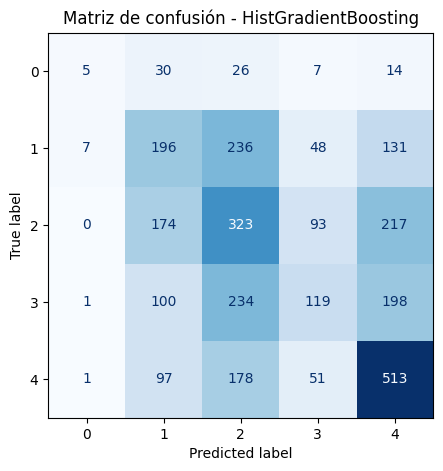

In [33]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_test,
    ax=ax,
    cmap="Blues",
    colorbar=False
)
ax.set_title("Matriz de confusión - HistGradientBoosting")
plt.show()


## 8. Validación cruzada 5-Fold

Acá replicamos la lógica de tu notebook de LightGBM, pero con HistGradientBoosting.
Se calcula:
- QWK por fold
- Accuracy por fold
- promedio final
- predicciones OOF
- predicciones promedio para test


In [34]:
folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

n_classes = y_train.nunique()
oof_preds = np.zeros((len(X_train), n_classes))
test_preds = np.zeros((len(X_test), n_classes))

fold_results = []

for fold, (trn_idx, val_idx) in enumerate(folds.split(X_train, y_train), start=1):
    print(f"\n================ FOLD {fold}/{N_SPLITS} ================")

    X_tr = X_train.iloc[trn_idx].copy()
    y_tr = y_train.iloc[trn_idx].copy()
    X_val = X_train.iloc[val_idx].copy()
    y_val = y_train.iloc[val_idx].copy()

    model = HistGradientBoostingClassifier(**hgb_params)
    model.fit(X_tr, y_tr)

    val_pred = model.predict(X_val)
    val_proba = model.predict_proba(X_val)
    test_proba = model.predict_proba(X_test)

    oof_preds[val_idx] = val_proba
    test_preds += test_proba / N_SPLITS

    qwk_fold = cohen_kappa_score(y_val, val_pred, weights="quadratic")
    acc_fold = accuracy_score(y_val, val_pred)
    bal_acc_fold = balanced_accuracy_score(y_val, val_pred)

    fold_results.append({
        "fold": fold,
        "qwk": qwk_fold,
        "accuracy": acc_fold,
        "balanced_accuracy": bal_acc_fold,
        "n_iter": model.n_iter_
    })

    print(f"QWK fold          : {qwk_fold:.5f}")
    print(f"Accuracy fold     : {acc_fold:.5f}")
    print(f"Balanced Acc fold : {bal_acc_fold:.5f}")
    print(f"Iteraciones       : {model.n_iter_}")

df_folds = pd.DataFrame(fold_results)
display(df_folds)

oof_classes = np.argmax(oof_preds, axis=1)
test_classes = np.argmax(test_preds, axis=1)

qwk_oof = cohen_kappa_score(y_train, oof_classes, weights="quadratic")
qwk_test_cv = cohen_kappa_score(y_test, test_classes, weights="quadratic")
acc_test_cv = accuracy_score(y_test, test_classes)
bal_acc_test_cv = balanced_accuracy_score(y_test, test_classes)

print("\n================ RESUMEN FINAL CV ================")
print(f"QWK OOF                 : {qwk_oof:.5f}")
print(f"QWK TEST (promedio CV)  : {qwk_test_cv:.5f}")
print(f"Accuracy TEST           : {acc_test_cv:.5f}")
print(f"Balanced Accuracy TEST  : {bal_acc_test_cv:.5f}")
print("\nPromedio por fold:")
print(df_folds.mean(numeric_only=True).round(5))



================ FOLD 1/5 ================
QWK fold          : 0.36734
Accuracy fold     : 0.41059
Balanced Acc fold : 0.33177
Iteraciones       : 94

================ FOLD 2/5 ================
QWK fold          : 0.34759
Accuracy fold     : 0.40684
Balanced Acc fold : 0.33186
Iteraciones       : 111

================ FOLD 3/5 ================
QWK fold          : 0.36526
Accuracy fold     : 0.41100
Balanced Acc fold : 0.32691
Iteraciones       : 87

================ FOLD 4/5 ================
QWK fold          : 0.35820
Accuracy fold     : 0.39308
Balanced Acc fold : 0.31772
Iteraciones       : 97

================ FOLD 5/5 ================
QWK fold          : 0.36513
Accuracy fold     : 0.42035
Balanced Acc fold : 0.33899
Iteraciones       : 90


,fold,qwk,accuracy,balanced_accuracy,n_iter
0,1,0.367343,0.410588,0.331770,94
1,2,0.347595,0.406836,0.331859,111
2,3,0.365261,0.411005,0.326906,87
3,4,0.358202,0.393080,0.317718,97
4,5,0.365135,0.420350,0.338991,90



================ RESUMEN FINAL CV ================
QWK OOF                 : 0.36066
QWK TEST (promedio CV)  : 0.31267
Accuracy TEST           : 0.38713
Balanced Accuracy TEST  : 0.32096

Promedio por fold:
fold                  3.00000
qwk                   0.36071
accuracy              0.40837
balanced_accuracy     0.32945
n_iter               95.80000
dtype: float64


## 9. Cómo evoluciona el modelo por iteración

Esto te sirve para **ver cómo va funcionando** el modelo.  
Usamos `staged_predict` para calcular el QWK del holdout test a medida que avanzan las iteraciones del boosting.


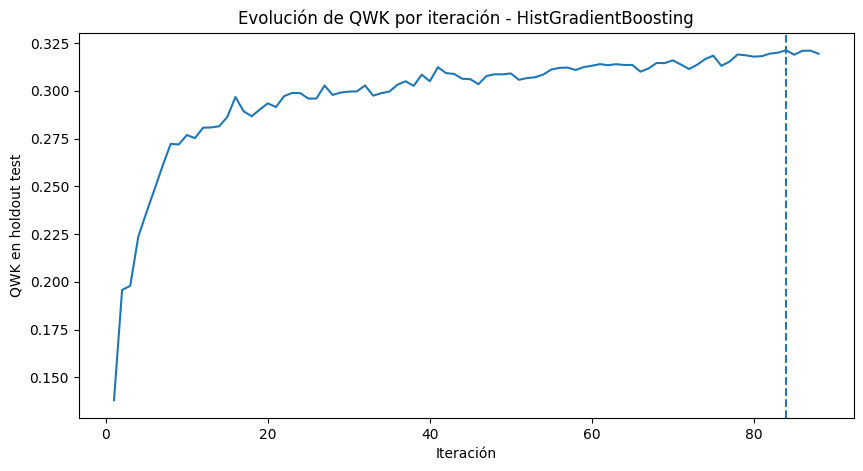

Mejor iteración observada en holdout: 84
Mejor QWK observado en holdout      : 0.32121


In [35]:
qwk_by_iteration = []

for preds_iter in model_hgb.staged_predict(X_test):
    score_iter = cohen_kappa_score(y_test, preds_iter, weights="quadratic")
    qwk_by_iteration.append(score_iter)

best_iter_plot = int(np.argmax(qwk_by_iteration) + 1)
best_score_plot = float(np.max(qwk_by_iteration))

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(qwk_by_iteration) + 1), qwk_by_iteration)
plt.axvline(best_iter_plot, linestyle="--")
plt.xlabel("Iteración")
plt.ylabel("QWK en holdout test")
plt.title("Evolución de QWK por iteración - HistGradientBoosting")
plt.show()

print(f"Mejor iteración observada en holdout: {best_iter_plot}")
print(f"Mejor QWK observado en holdout      : {best_score_plot:.5f}")


## 10. Permutation importance

Como inspección del modelo, en vez de una importancia “interna” tipo gain, calculamos el impacto real sobre la métrica QWK cuando permutamos cada variable.


,feature,importance_mean,importance_std
0,Age,0.101544,0.009864
1,Breed1,0.089050,0.012496
2,Breed2,0.025377,0.008316
3,Photos_per_Pet,0.020108,0.008703
4,Age_x_PhotoAmt,0.013442,0.003356
5,State,0.012117,0.004139
6,Age_x_MaturitySize,0.011442,0.002017
7,Sterilized,0.009743,0.007716
8,Salud_Completa,0.006488,0.004930
9,Dewormed,0.006482,0.002904


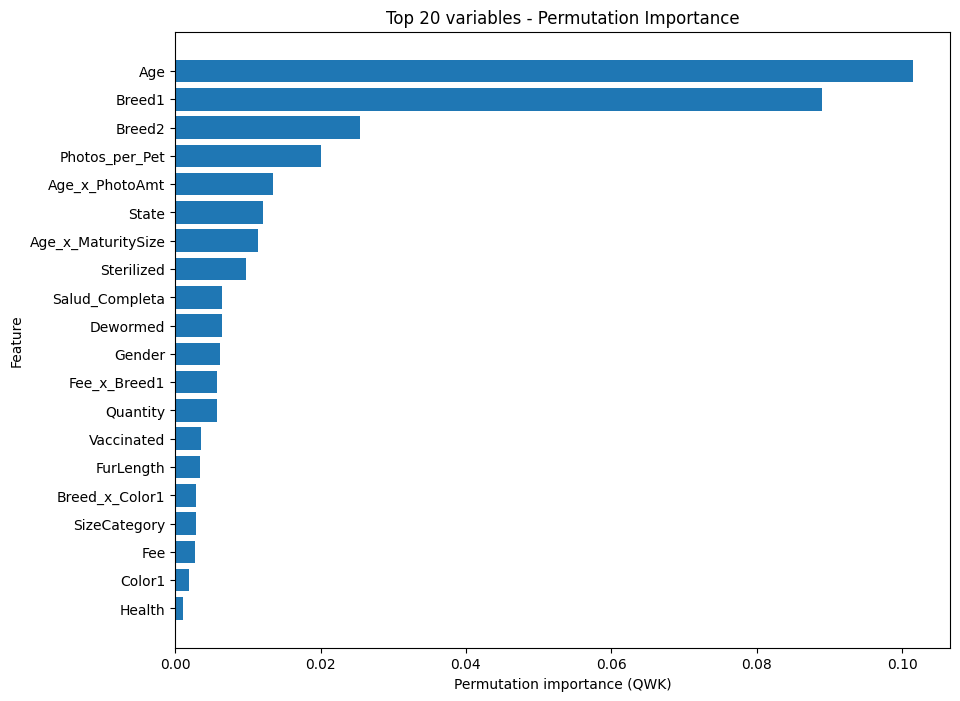

In [36]:
qwk_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

perm = permutation_importance(
    estimator=model_hgb,
    X=X_test,
    y=y_test,
    scoring=qwk_scorer,
    n_repeats=5,
    random_state=SEED,
    n_jobs=-1
)

df_perm = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

display(df_perm.head(20))

plt.figure(figsize=(10, 8))
top_k = 20
plot_df = df_perm.head(top_k).sort_values("importance_mean", ascending=True)
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Permutation importance (QWK)")
plt.ylabel("Feature")
plt.title("Top 20 variables - Permutation Importance")
plt.show()


## 11. Optuna opcional para tunear HistGradientBoosting

Este bloque es opcional.  
Primero probá el notebook hasta acá. Si todo corre bien, recién después usá Optuna.


In [19]:
!pip install optuna


   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 13.3 MB/s  0:00:00

   ---------------------------------------- 0/7 [tqdm]
   ----- ---------------------------------- 1/7 [Mako]
   ----- ---------------------------------- 1/7 [Mako]
   ----------- ---------------------------- 2/7 [greenlet]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   -------------------

In [37]:
import optuna

def objective_hgb(trial):
    params = {
        "loss": "log_loss",
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.20, log=True),
        "max_iter": trial.suggest_int("max_iter", 200, 800),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 63),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 80),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-3, 10.0, log=True),
        "max_features": trial.suggest_float("max_features", 0.60, 1.00),
        "max_bins": 255,
        "categorical_features": "from_dtype",
        "early_stopping": True,
        "validation_fraction": 0.10,
        "n_iter_no_change": 30,
        "tol": 1e-7,
        "verbose": 0,
        "random_state": SEED
    }

    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_scores = []

    for trn_idx, val_idx in folds.split(X_train, y_train):
        X_tr = X_train.iloc[trn_idx].copy()
        y_tr = y_train.iloc[trn_idx].copy()
        X_val = X_train.iloc[val_idx].copy()
        y_val = y_train.iloc[val_idx].copy()

        model = HistGradientBoostingClassifier(**params)
        model.fit(X_tr, y_tr)

        val_pred = model.predict(X_val)
        score = cohen_kappa_score(y_val, val_pred, weights="quadratic")
        fold_scores.append(score)

    return float(np.mean(fold_scores))

study_hgb = optuna.create_study(direction="maximize", study_name="PetFinder_HGB_Optuna")
study_hgb.optimize(objective_hgb, n_trials=30)

print("\n=== MEJOR RESULTADO OPTUNA ===")
print("Best QWK CV:", study_hgb.best_value)
print("Best params:")
for k, v in study_hgb.best_params.items():
    print(f"  {k}: {v}")


[I 2026-04-13 00:15:48,031] A new study created in memory with name: PetFinder_HGB_Optuna
[I 2026-04-13 00:15:57,508] Trial 0 finished with value: 0.36073120228146915 and parameters: {'learning_rate': 0.034910808129949344, 'max_iter': 738, 'max_leaf_nodes': 30, 'max_depth': 7, 'min_samples_leaf': 49, 'l2_regularization': 0.03497139749383806, 'max_features': 0.675600245964821}. Best is trial 0 with value: 0.36073120228146915.
[I 2026-04-13 00:16:04,156] Trial 1 finished with value: 0.34717430871808674 and parameters: {'learning_rate': 0.18349622975328886, 'max_iter': 262, 'max_leaf_nodes': 51, 'max_depth': 11, 'min_samples_leaf': 22, 'l2_regularization': 0.012257220668468375, 'max_features': 0.7434267199258933}. Best is trial 0 with value: 0.36073120228146915.
[I 2026-04-13 00:16:08,685] Trial 2 finished with value: 0.35483597466064065 and parameters: {'learning_rate': 0.07174143169107797, 'max_iter': 480, 'max_leaf_nodes': 17, 'max_depth': 4, 'min_samples_leaf': 28, 'l2_regularization'


=== MEJOR RESULTADO OPTUNA ===
Best QWK CV: 0.36299604315343637
Best params:
  learning_rate: 0.020525920734663475
  max_iter: 605
  max_leaf_nodes: 16
  max_depth: 6
  min_samples_leaf: 77
  l2_regularization: 6.481964173995612
  max_features: 0.6111482928608531


## 12. Modelo final con mejores parámetros de Optuna

Solo corré esta celda si ya terminaste la optimización.


In [38]:
best_hgb_params = {
    "loss": "log_loss",
    "max_bins": 255,
    "categorical_features": "from_dtype",
    "early_stopping": True,
    "validation_fraction": 0.10,
    "n_iter_no_change": 30,
    "tol": 1e-7,
    "verbose": 1,
    "random_state": SEED,
    **study_hgb.best_params
}

best_model_hgb = HistGradientBoostingClassifier(**best_hgb_params)
best_model_hgb.fit(X_train, y_train)

best_pred_test = best_model_hgb.predict(X_test)

print("QWK test con mejores params:", cohen_kappa_score(y_test, best_pred_test, weights="quadratic"))
print("Accuracy test:", accuracy_score(y_test, best_pred_test))
print("Balanced accuracy test:", balanced_accuracy_score(y_test, best_pred_test))
print("Iteraciones usadas:", best_model_hgb.n_iter_)


Binning 0.002 GB of training data: 0.047 s
Binning 0.000 GB of validation data: 0.000 s
Fitting gradient boosted rounds:
Fit 1495 trees in 3.738 s, (23316 total leaves)
Time spent computing histograms: 0.704s
Time spent finding best splits:  0.959s
Time spent applying splits:      0.599s
Time spent predicting:           0.063s
QWK test con mejores params: 0.3066002300760421
Accuracy test: 0.3821273757919306
Balanced accuracy test: 0.3068039574960768
Iteraciones usadas: 299


## 13. Conclusión práctica

Si querés comparar de forma justa:
1. corré este notebook de HistGradientBoosting;
2. dejá fijo el mismo `train/test split`;
3. compará contra tu LightGBM con:
   - QWK en test
   - QWK OOF
   - estabilidad por fold
   - tiempo de entrenamiento

### Próximo paso sugerido
Si HistGradientBoosting te corre bien, el siguiente experimento que te conviene hacer es:
- **misma ingeniería de variables**
- **mismo split**
- comparar:
  - LightGBM
  - CatBoost
  - HistGradientBoosting
